<a href="https://colab.research.google.com/github/SampMark/Machine-Learning/blob/main/Gaussian_Mixture_Model_(GMM)_K_Means_vs_Expectation_Maximization_(EM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **_Gaussian Mixture Model_ (GMM), K-Means versus EM (_Expectation-Maximization_)**

Neste notebook iremos explorar _mixture models_ aplicados a distribuições gaussianas, destacando como essa abordagem possibilita uma modelagem mais refinada e flexível aos dados, especialmente quando se observa que existem vários agrupamentos nos dados.

Os Gaussian Mixture Models (GMM) são considerados uma ferramenta versátil para modelar dados heterogêneos, combinando a flexibilidade de múltiplas gaussianas com uma abordagem probabilística para inferência. São uma extensão poderosa de distribuições gaussianas únicas, permitindo modelar dados complexos que não seguem uma única distribuição normal.

A ideia central desses modelos é que, embora seja possível representar os dados com uma única distribuição gaussiana (mesmo que com alta variância), isto pode mascarar a estrutura interna dos dados. Especialmente quando estes poderiam ser agrupados em dois ou mais clusters, assim uma **única gaussiana** poderia ajustar os dados **inadequadamente** – uma vez que ela pode abranger vários agrupamentos com uma única média e uma única variância, desprezando-se assim informações importantes sobre a heterogeneidade do conjunto de dados. Por exemplo, imagine dois grupos de pontos em lados opostos de um plano. Uma única gaussiana "achatada" pode até cobrir todos os pontos, mas ignora a estrutura de clusters subjacentes.  

### **Definição Básica**  

Conforme mencionado, uma única gaussiana (com média μ e variância σ²) não irá capturar estruturas complexas em dados, como a presença de múltiplos agrupamentos (*clusters*). Por exemplo, dados com dois grupos distintos seriam mal representados por uma única gaussiana de alta variância.

Assim, assume-se que os modelos de mistura de gaussianas:
* Há um número K de componentes (ou clusters),em que cada componente é uma gaussiana com seus próprios parâmetros.
* Cada componente j (para j = 1, 2, ..., K) possui uma média (μⱼ) e uma variância (σ²ⱼ), que descrevem geometricamente a posição (centro) do cluster e o quão dispersos estão os dados ao redor dessa média.
* Cada componente possui um peso de mistura (ou probabilidade) que indica a fração dos dados que é gerada por aquele componente. Esses pesos formam uma distribuição multinomial (isto é, os pesos são não-negativos e somam 1).

Em suma, uma "Mistura de Gaussianas combina **K componentes gaussianos**, cada um com seus próprios parâmetros (μⱼ, σ²ⱼ) e um **peso de mistura** (πⱼ), que define a probabilidade de um ponto pertencer a cada componente.

  - **Modelo generativo**:  
    1. **Passo 1**: Seleciona-se um componente $j$ com probabilidade $\pi_j$ (como "rolar um dado" com probabilidades desiguais).  
    2. **Passo 2**: Amostra-se um ponto da gaussiana $\mathcal{N}(\mu_j, \sigma^2_j)$.  

### **Componentes e funcionamento do GMM**

o processo de geração de um ponto em um modelo de mistura é um processo de duas etapas:
1. Primeiro, decide-se de qual componente (cluster) o ponto virá. Isto é feito amostrando de uma multinomial definida pelos pesos de mistura (como “lançar um dado” para escolher o cluster).
2. Em seguida, uma vez escolhido o componente, o ponto é gerado segundo a gaussiana correspondente, que tem parâmetros específicos (μⱼ e σ²ⱼ).

O foco desta abordagem é estimar, a partir dos dados observados, o conjunto de parâmetros que define o modelo generativo. Esses parâmetros incluem os pesos da multinomial (p₁,…,pₖ), as médias (μ₁,…,μₖ) e as variâncias (σ²₁,…,σ²ₖ) de cada componente gaussiana. Uma vez estimados, esses parâmetros permitem que se faça uma atribuição “suave” (_soft assignment_) dos dados aos clusters. Ou seja, determinar a probabilidade de cada ponto pertencer a cada uma das componentes.

Dessa forma, o modelo não se restringe a uma “atribuição dura” (_hard assignment_) dos pontos a um único cluster, como no k-means, mas permite uma associação “suave”, em que cada ponto pode ter diferentes probabilidades de pertencer a cada um dos componentes do modelo, possibilitando uma modelagem mais precisa da incerteza e da estrutura dos dados.

- **Parâmetros do modelo**:  
  - **Pesos de mistura ($\pi_j$)**:  
    - Representam a proporção de cada componente no modelo.  
    - Devem satisfazer $\sum_{j=1}^K \pi_j = 1$ (são uma distribuição multinomial).  
  - **Médias ($\mu_j$) e variâncias ($\sigma^2_j$)**:  
    - Cada componente gaussiano tem sua própria média (posição) e variância (espalhamento).  

- **Probabilidade de um ponto**:  
  A probabilidade total de um ponto $x$ é dada pela **média ponderada** das probabilidades de cada componente:  
  $$
  P(x) = \sum_{j=1}^K \pi_j \cdot \mathcal{N}(x | \mu_j, \sigma^2_j)
  $$


### **Comparação com Outros Métodos**  
- **K-means vs. GMM**:  
  O **K-means** faz **agrupamento rígido** (cada ponto pertence a um único cluster). O **GMM** permite o **agrupamento suave** (probabilidades de pertencer a múltiplos clusters). Por exemplo, um ponto entre dois clusters terá probabilidades $P(j=1 | x)$ e $P(j=2 | x)$, não uma atribuição binária.  

- **Vantagens do GMM**:  
  - Modela incertezas e sobreposições entre clusters.
  - Captura formas complexas de distribuições (multimodais).  

### **Aplicações Práticas**

Esses modelos generativos podem ser empregados, por exemplo, em tarefas de classificação. É comum estimar-se um modelo de mistura para a classe positiva e outro para a classe negativa, e na hora de classificar um novo ponto, compara a probabilidade (ou verossimilhança) de o ponto ter sido gerado por cada modelo. Em linhas gerais, têm as seguintes aplicações:
  - Estimar um GMM para cada classe (ex: "positivo" e "negativo").  
  - Classificar um novo ponto pela classe com maior probabilidade $P(x | \text{classe})$.  
  - Segmentação de imagens (agrupar pixels por cores/texturas).  
  - Detecção de anomalias (pontos com baixa probabilidade em todos os componentes).
  - Tarefas como _matrix completion_, usadas em sistemas de recomendação.



### **5. Desafios e Considerações**  
- **Escolha do número de componentes (K)**:  
  Métodos como o **Critério de Informação Bayesiano (BIC)** ajudam a selecionar $K$.  
- **Estimação de parâmetros**:  
  Usa-se o algoritmo **Expectation-Maximization (EM)** para ajustar $\pi_j$, $\mu_j$, e $\sigma^2_j$.  
- **Curse of Dimensionality**: GMMs podem perder eficácia em espaços de alta dimensão devido à complexidade computacional e escassez de dados.

Os GMM são portanto uma ferramenta útil para analisar cenários de dados que exibem uma estrutura de agrupamentos complexos, permitindo capturar tanto a localização (por meio de $μ$) quanto a variabilidade (por meio de $σ²$) de cada cluster, bem como a proporção relativa de cada grupo na população.



In [1]:
# Instalações necessárias
!pip install scipy matplotlib

In [2]:
# Importações
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from scipy.special import logsumexp
from typing import NamedTuple, Tuple
import requests

In [3]:
# @title **Classe `GaussianMixture`**

# --- Definição da Estrutura da Mistura ---

class GaussianMixture(NamedTuple):
    """Tupla contendo os parâmetros de uma mistura gaussiana.
    Assume variâncias isotrópicas (escalares) para cada componente.
    """
    mu: np.ndarray   # Médias (K, d) - cada linha corresponde à média de um componente gaussiano
    var: np.ndarray  # Variâncias (K,) - cada linha corresponde à variância de um componente
    p: np.ndarray    # Pesos (K,) - cada linha corresponde ao peso de um componente

In [4]:
# --- Configurações de plotagem dos clusters ---
def plot(X: np.ndarray, mixture: GaussianMixture, post: np.ndarray, title: str, ax=None):
    K = post.shape[1]
    colors = plt.cm.tab10(np.linspace(0, 1, K)) # Suporte a mais clusters

    if ax is None:
        ax = plt.gca()

    ax.set_title(title)
    ax.set_xlim(-20, 20)
    ax.set_ylim(-20, 20)

    # Plotagem
    assignments = np.argmax(post, axis=1)
    for j in range(K):
        cluster_points = X[assignments == j]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
                   color=colors[j], alpha=0.6, label=f'Cluster {j+1}')

        mu = mixture.mu[j]
        sigma = np.sqrt(mixture.var[j])
        circle = plt.Circle(mu, sigma, color=colors[j], fill=False, linestyle='--', alpha=0.7)
        ax.add_patch(circle)
        ax.text(mu[0], mu[1], f'μ=({mu[0]:.2f},{mu[1]:.2f})\nσ={sigma:.2f}',
                ha='center', va='center', fontsize=8)

    ax.grid(True)
    ax.legend(loc='upper right')
    ax.axis('equal')

In [5]:
# @title **Implantação do K-Means**

# ================== IMPLEMENTAÇÃO DO K-MEANS ==================
def kmeans_estep(X: np.ndarray, mixture: GaussianMixture) -> np.ndarray:
    """
    Etapa E do algoritmo K-means.

    Para cada ponto em X, calcula a distância euclidiana (ao quadrado)
    para cada centro (mu) dos clusters presentes no objeto 'mixture'. Em
    seguida, para cada ponto, seleciona o cluster cuja distância é
    mínima, retornando uma atribuição binária (codificação one-hot)
    indicando o cluster mais próximo.

    Parâmetros:
        X (np.ndarray): Matriz de dados de entrada de forma (n_samples, n_features),
                        onde cada linha representa um ponto (exemplo).
        mixture (GaussianMixture): Objeto que contém os parâmetros do modelo,
                                   incluindo 'mu' (centros dos clusters).

    Retorna:
        np.ndarray: Matriz de atribuição binária de forma (n_samples, K),
                    onde K é o número de clusters. Cada linha possui exatamente
                    um valor 1 (cluster mais próximo) e zeros para os demais.
    """
    # Calcula a soma das diferenças ao quadrado entre cada ponto e cada centro.
    # X[:, np.newaxis] tem forma (n_samples, 1, n_features) e mixture.mu tem forma (K, n_features)
    # O resultado 'distances' terá forma (n_samples, K)
    distances = np.sum((X[:, np.newaxis] - mixture.mu) ** 2, axis=2)

    # Para cada ponto, seleciona o índice do centro com a menor distância
    closest = np.argmin(distances, axis=1)

    # Retorna a codificação one-hot das atribuições: para cada ponto, uma linha com 1 na
    # posição correspondente ao cluster mais próximo
    return np.eye(mixture.mu.shape[0])[closest]


def kmeans_mstep(X: np.ndarray, post: np.ndarray) -> Tuple[GaussianMixture, float]:
    """
    Etapa M do algoritmo K-means.

    Dada a atribuição (matriz 'post') dos pontos aos clusters (obtida na etapa E),
    atualiza os parâmetros do modelo (novos centros, variâncias e pesos dos clusters)
    que minimizam a soma dos erros quadráticos.

    Parâmetros:
        X (np.ndarray): Matriz de dados de entrada de forma (n_samples, n_features).
        post (np.ndarray): Matriz de atribuição dos pontos aos clusters de forma (n_samples, K),
                           onde cada linha é uma codificação one-hot indicando a qual cluster
                           cada ponto foi atribuído.

    Retorna:
        Tuple[GaussianMixture, float]:
            - Uma instância de GaussianMixture com os parâmetros atualizados:
              * mu: novos centros dos clusters, de forma (K, n_features).
              * var: variâncias (ou parâmetro de dispersão) de cada cluster, vetor de tamanho K.
              * p: pesos de cada cluster (proporção de pontos), vetor de tamanho K.
            - O custo total, que é a soma dos erros quadráticos (SSE) de todas as atribuições.
    """
    n, d = X.shape                     # n: número de pontos, d: dimensionalidade
    K = post.shape[1]                  # Número de clusters
    n_hat = post.sum(axis=0)           # Número (soft) de pontos em cada cluster (contagem por coluna)
    p = n_hat / n                      # Probabilidade (peso) de cada cluster = fração dos pontos atribuídos

    # Atualiza as médias (centros) dos clusters:
    # Calcula a média ponderada dos pontos para cada cluster
    mu = post.T @ X / n_hat[:, None]   # post.T tem forma (K, n) => mu resultante tem forma (K, d)

    # Cálculo do erro quadrático total (Soma dos Erros Quadráticos - SSE) para cada cluster:
    # Expande X para que cada ponto seja comparado com cada centro: diff terá forma (n, K, d)
    diff = X[:, np.newaxis, :] - mu    # Diferença entre cada ponto e cada centro
    squared_diff = diff ** 2           # Diferença ao quadrado, forma (n, K, d)

    # Multiplica as diferenças ao quadrado pelos pesos de atribuição (one-hot) para cada ponto,
    # de forma que apenas os pontos atribuídos a cada cluster contribuam para o erro.
    weighted_squared_diff = squared_diff * post[:, :, np.newaxis]

    # Soma as diferenças ao quadrado sobre todos os pontos e sobre a dimensão das features, resultando
    # em um vetor de SSE para cada cluster (tamanho K)
    sse = np.sum(weighted_squared_diff, axis=(0, 2))

    # Calcula a variância para cada cluster:
    # Divide o SSE pelo produto da dimensionalidade e pelo número de pontos em cada cluster
    var = sse / (d * n_hat)

    # O custo total é a soma dos SSE para todos os clusters
    cost = np.sum(sse)

    # Retorna GaussianMixture com os parâmetros atualizados
    # e o custo associado a essa iteração.
    return GaussianMixture(mu, var, p), cost


def kmeans_run(X: np.ndarray, mixture: GaussianMixture, max_iter: int = 100) -> Tuple[GaussianMixture, np.ndarray, float]:
    """
    Executa o algoritmo K-means iterativamente.

    Este procedimento utiliza as etapas E (kmeans_estep) e M (kmeans_mstep) de forma
    iterativa para atualizar os parâmetros do modelo até convergência ou até atingir
    o número máximo de iterações.

    Parâmetros:
        X (np.ndarray): Matriz de dados com forma (n_samples, n_features).
        mixture (GaussianMixture): Instância inicial do modelo com os parâmetros iniciais (centros, variâncias e pesos).
        max_iter (int, opcional): Número máximo de iterações. Padrão é 100.

    Retorna:
        Tuple[GaussianMixture, np.ndarray, float]:
            - O objeto GaussianMixture com os parâmetros finais atualizados.
            - A matriz de atribuição (posterior) final dos pontos, forma (n_samples, K).
            - O custo (custo total ou soma do erro quadrático) final.
    """
    prev_cost = np.inf  # Inicializa o custo anterior como infinito para facilitar a verificação de convergência
    # Inicializa a matriz de atribuição (posterior) com zeros; forma (n_samples, K)
    post = np.zeros((X.shape[0], mixture.mu.shape[0]))

    for it in range(max_iter):
        # Etapa E: Atribui cada ponto ao cluster mais próximo
        post = kmeans_estep(X, mixture)
        # Etapa M: Atualiza os parâmetros do modelo com base nas atribuições
        mixture, cost = kmeans_mstep(X, post)
        print(f"Iteração {it+1}: Custo = {cost:.2f}")
        # Verifica se a melhoria é menor que um limiar (convergência)
        if prev_cost - cost < 1e-4:
            print(f"Convergido após {it+1} iterações.")
            break
        prev_cost = cost  # Atualiza o custo anterior para a próxima iteração

    return mixture, post, cost

In [ ]:
# @title **Implantação do K-Means**

# ================== IMPLEMENTAÇÃO DO K-MEANS ==================
def kmeans_estep(X: np.ndarray, mixture: GaussianMixture) -> np.ndarray:
    """Atribuição binária aos clusters mais próximos."""
    distances = np.sum((X[:, np.newaxis] - mixture.mu) ** 2, axis=2)
    closest = np.argmin(distances, axis=1)
    return np.eye(mixture.mu.shape[0])[closest]

def kmeans_mstep(X: np.ndarray, post: np.ndarray) -> Tuple[GaussianMixture, float]:
    """Atualização das médias, variâncias e pesos."""
    n, d = X.shape
    K = post.shape[1]
    n_hat = post.sum(axis=0)
    p = n_hat / n
    mu = post.T @ X / n_hat[:, None]

    # Cálculo do SSE por cluster
    diff = X[:, np.newaxis, :] - mu  # (n, K, d)
    squared_diff = diff ** 2
    weighted_squared_diff = squared_diff * post[:, :, np.newaxis]
    sse = np.sum(weighted_squared_diff, axis=(0, 2))  # (K,)

    var = sse / (d * n_hat)  # Variância por cluster
    cost = np.sum(sse)  # Custo total

    return GaussianMixture(mu, var, p), cost

def kmeans_run(X: np.ndarray, mixture: GaussianMixture, max_iter: int = 100) -> Tuple[GaussianMixture, np.ndarray, float]:
    """Execução do algoritmo K-means."""
    prev_cost = np.inf
    post = np.zeros((X.shape[0], mixture.mu.shape[0]))
    for it in range(max_iter):
        post = kmeans_estep(X, mixture)
        mixture, cost = kmeans_mstep(X, post)
        print(f"Iteração {it+1}: Custo = {cost:.2f}")
        if prev_cost - cost < 1e-4:
            print(f"Convergido após {it+1} iterações.")
            break
        prev_cost = cost
    return mixture, post, cost

## **Funcionamento do algoritmo _Expectation-Maximization_ (EM)**

Embora, na formulação do modelo gerativo, a distribuição de probabilidade dos dados já esteja definida, o problema fundamental é a estimação dos parâmetros desconhecidos com base no conjunto de dados.

Esse problema, conhecido como "_chicken and egg_", surge porque, para calcular a probabilidade de pertencimento de um ponto a um cluster, seria necessário conhecer os parâmetros da gaussiana associada ao cluster, e esses parâmetros só podem ser estimados se soubermos a qual componente cada ponto pertence.

Assim, o algoritmo Expectation-Maximization (EM) é adotado para resolver essa interdependência, seu funcionamento alterna entre uma etapa de Expectation (E), na qual se calcula a probabilidade (ou “_soft count_”) de cada ponto pertencer a cada componente, e uma etapa de Maximization (M), na qual se re-estimam os parâmetros com base nessas probabilidades, até que a verossimilhança convirja.

### **Inicialização Aleatória dos Parâmetros**

O algoritmo EM começa com uma estimativa inicial dos parâmetros do modelo, que inclui os pesos de mistura $(p₁, …, pₖ)$, as médias $(μ₁, …, μₖ)$ e as variâncias $(σ²₁, …, σ²ₖ)$ para cada uma das k componentes do modelo.

Essa inicialização é feita de forma aleatória – de modo análogo à escolha aleatória dos **centroides** no **k-means**. Embora seja importante que a estratégia de inicialização possa afetar os resultados finais, é garantido que o EM convirja apenas localmente.

### **E Step – Cálculo das Probabilidades (Posteriores)**  

Na etapa de Expectation (E-step), o objetivo é calcular, para cada ponto de dados $xᵢ$ e para cada componente $j$, a probabilidade condicional $p(j|xᵢ)$, ou seja, a probabilidade de que a componente $j$ tenha gerado o ponto $xᵢ$, dado o conjunto atual de parâmetros.

Essa “atribuicão suave” substitui a função indicadora utilizada no "caso observado". Em outras palavras, em vez de dizer que um ponto pertence 100% a um cluster (0 ou 1), a estimativa $p(j|xᵢ)$ fornece um valor entre 0 e 1, refletindo **incerteza** nessa atribuição. Nessa etapa são computadas as probabilidades para todos os $n$ pontos e para cada um dos $K$ clusters.

### **M Step – Atualização dos Parâmetros**

Após calcular os valores de $p(j|xᵢ)$ para todos os pontos, a etapa de Maximization (M-step) consiste em atualizar os parâmetros do modelo, maximizando uma função proxy que se assemelha ao log-verossimilhança dos dados.

Neste passo, os “soft counts” $p(j|xᵢ)$ substituem as contagens "duras" (dos casos observados) na atualização dos parâmetros. Assim, são derivadas as fórmulas de atualização clássicas:

* A nova média de cada componente j é dada por  
$μ̂ⱼ = (Σᵢ p(j|xᵢ)·xᵢ) / (Σᵢ p(j|xᵢ))$.

* O novo peso de mistura para a componente j é atualizado como  $p̂ⱼ = (1/n)·Σᵢ p(j|xᵢ)$.
* A nova variância (ou matriz de covariância, se o modelo for generalizado) é atualizada com base nas distâncias quadráticas dos pontos à nova média, também ponderada pelas probabilidades $p(j|xᵢ)$.

### **Iteração e Convergência**  

Após a atualização dos parâmetros, o algoritmo calcula a verossimilhança (ou log-verossimilhança) dos dados com o novo conjunto de parâmetros. Se a variação nessa verossimilhança (por exemplo, a diferença entre o valor novo e o valor anterior) for menor que um limiar predefinido, o algoritmo é interrompido; caso contrário, ele repete as etapas E e M. Essa iteração garante que a cada ciclo a verossimilhança não diminua, convergindo para um máximo local.

### **Discussão de Complexidade e Garantias**  

Embora o EM aumente a verossimilhança a cada iteração, ele pode convergir a diferentes soluções, dependendo da escolha inicial dos parâmetros. Essa convergência local reforça a importância de uma boa inicialização. Por exemplo, utilizando o k-means para definir os centroides iniciais (e possivelmente uma estimativa global da variância) como ponto de partida.

Após a convergência, os parâmetros estimados (denotados com $hat$) representam o melhor ajuste do modelo aos dados sob o critério de máxima verossimilhança, servindo como base para aplicações, como por exemplo _matrix completion_.


In [6]:
# @title **Implantação do EM**

# ================== IMPLEMENTAÇÃO DO EM ==================
def gmm_estep(X: np.ndarray, mixture: GaussianMixture) -> Tuple[np.ndarray, float]:
    """Executa a Etapa E do algoritmo EM.

    Calcula as probabilidades posteriores (responsabilidades) de cada ponto de dado
    pertencer a cada componente da mistura e a log-verossimilhança total.

    Argumentos:
        X: (n, d) array contendo os dados. Assume-se que 0 representa
           valores faltantes.
        mixture: A mistura gaussiana atual.

    Retorna:
        Tuple[np.ndarray, float]:
            - post: (n, K) array das probabilidades posteriores p(z_i=k | x_i, theta)
            - log_likelihood: Log-verossimilhança total dos dados observados.
    """
    n, d = X.shape
    K = mixture.mu.shape[0]
    mask = (X != 0)
    log_p = np.log(np.clip(mixture.p, 1e-10, None))
    log_post = np.zeros((n, K))

    for k in range(K):
        diff = (X - mixture.mu[k]) * mask
        log_prob = -0.5 * (np.sum(diff**2, axis=1)/(mixture.var[k] + 1e-8))
        log_prob -= 0.5 * mask.sum(axis=1) * np.log(2 * np.pi * mixture.var[k])
        log_post[:, k] = log_p[k] + log_prob

    log_likelihood = logsumexp(log_post, axis=1).sum()
    post = np.exp(log_post - logsumexp(log_post, axis=1, keepdims=True))
    post = np.nan_to_num(post, nan=1/K)
    return post, log_likelihood

def gmm_mstep(X: np.ndarray, post: np.ndarray, old_mixture: GaussianMixture) -> GaussianMixture:
    """Executa a Etapa M do algoritmo EM.

    Atualiza os parâmetros da mistura (médias, variâncias, pesos)
    usando as probabilidades posteriores calculadas na Etapa E.

    Argumentos:
        X: (n, d) array contendo os dados (0 representa faltante).
        post: (n, K) array das probabilidades posteriores p(z_i=k | x_i).
        old_mixture: A mistura gaussiana da iteração anterior (usada para
                     manter variância se um componente não tiver responsabilidade).

    Retorna:
        GaussianMixture: A nova mistura gaussiana com parâmetros atualizados.
    """
    n, d = X.shape
    K = post.shape[1]
    mask = (X != 0)
    X_filled = np.where(mask, X, 0)

    new_p = post.sum(axis=0)/n
    weighted_X = post.T @ X_filled
    sum_weights = post.T @ mask
    new_mu = np.divide(weighted_X, sum_weights, where=sum_weights > 1e-8, out=old_mixture.mu.copy())

    diff = (X_filled[:, None] - new_mu)**2
    weighted_diff = (post[:, :, None] * diff * mask[:, None]).sum(axis=(0, 2))
    sum_weights_total = (post * mask.sum(axis=1)[:, None]).sum(axis=0)
    new_var = np.divide(weighted_diff, sum_weights_total, where=sum_weights_total > 1e-8, out=old_mixture.var.copy())
    return GaussianMixture(new_mu, np.clip(new_var, 1e-6, None), new_p)

def gmm_run(X: np.ndarray, initial_mixture: GaussianMixture, max_iter: int = 100, tol: float = 1e-6):
    """Executa o algoritmo EM para ajustar a mistura gaussiana aos dados.

    Argumentos:
        X: (n, d) array contendo os dados (0 representa faltante).
        initial_mixture: A mistura gaussiana inicial.
        max_iter: Número máximo de iterações do EM.
        tol: Tolerância para a mudança relativa na log-verossimilhança para convergência.

    Retorna:
        Tuple[GaussianMixture, np.ndarray, float]:
            - mixture: A mistura gaussiana final ajustada.
            - post: As probabilidades posteriores finais.
            - log_likelihood: A log-verossimilhança final.
    """
    mixture = initial_mixture
    log_likelihood_prev = -np.inf
    for iter in range(max_iter):
        post, log_likelihood = gmm_estep(X, mixture)
        old_mixture = mixture
        mixture = gmm_mstep(X, post, mixture)
        print(f"Iteração {iter+1}: Log-verossimilhança = {log_likelihood:.2f}")
        if iter > 0 and (log_likelihood - log_likelihood_prev) < tol * abs(log_likelihood_prev):
            print(f"Convergido após {iter+1} iterações.")
            break
        if log_likelihood < log_likelihood_prev:
            mixture = old_mixture
            break
        log_likelihood_prev = log_likelihood
    return mixture, post, log_likelihood

In [7]:
# @title Carregamento dos dados...

# ================== CARREGAMENTO DOS DADOS ==================
url = "https://raw.githubusercontent.com/SampMark/files/refs/heads/main/toy_data.txt"
response = requests.get(url)
X = np.loadtxt(response.iter_lines())
print("Dimensões dos dados:", X.shape)
X[:5]

Dimensões dos dados: (250, 2)


array([[-1.636,  2.413],
       [-2.957,  2.296],
       [-2.871,  1.832],
       [-2.696,  1.327],
       [-2.272,  1.738]])


========== Teste: K-means ==========
Iteração 1: Custo = 5462.30
Iteração 2: Custo = 5462.30
Convergido após 2 iterações.
Iteração 1: Custo = 5462.30
Iteração 2: Custo = 5462.30
Convergido após 2 iterações.
Iteração 1: Custo = 5462.30
Iteração 2: Custo = 5462.30
Convergido após 2 iterações.
Iteração 1: Custo = 5462.30
Iteração 2: Custo = 5462.30
Convergido após 2 iterações.
Iteração 1: Custo = 5462.30
Iteração 2: Custo = 5462.30
Convergido após 2 iterações.
Iteração 1: Custo = 1754.18
Iteração 2: Custo = 1693.58
Iteração 3: Custo = 1684.91
Iteração 4: Custo = 1684.91
Convergido após 4 iterações.
Iteração 1: Custo = 1723.47
Iteração 2: Custo = 1686.94
Iteração 3: Custo = 1684.91
Iteração 4: Custo = 1684.91
Convergido após 4 iterações.
Iteração 1: Custo = 4852.82
Iteração 2: Custo = 4348.53
Iteração 3: Custo = 1882.33
Iteração 4: Custo = 1684.91
Iteração 5: Custo = 1684.91
Convergido após 5 iterações.
Iteração 1: Custo = 4872.55
Iteração 2: Custo = 2465.93
Iteração 3: Custo = 1733.58
It

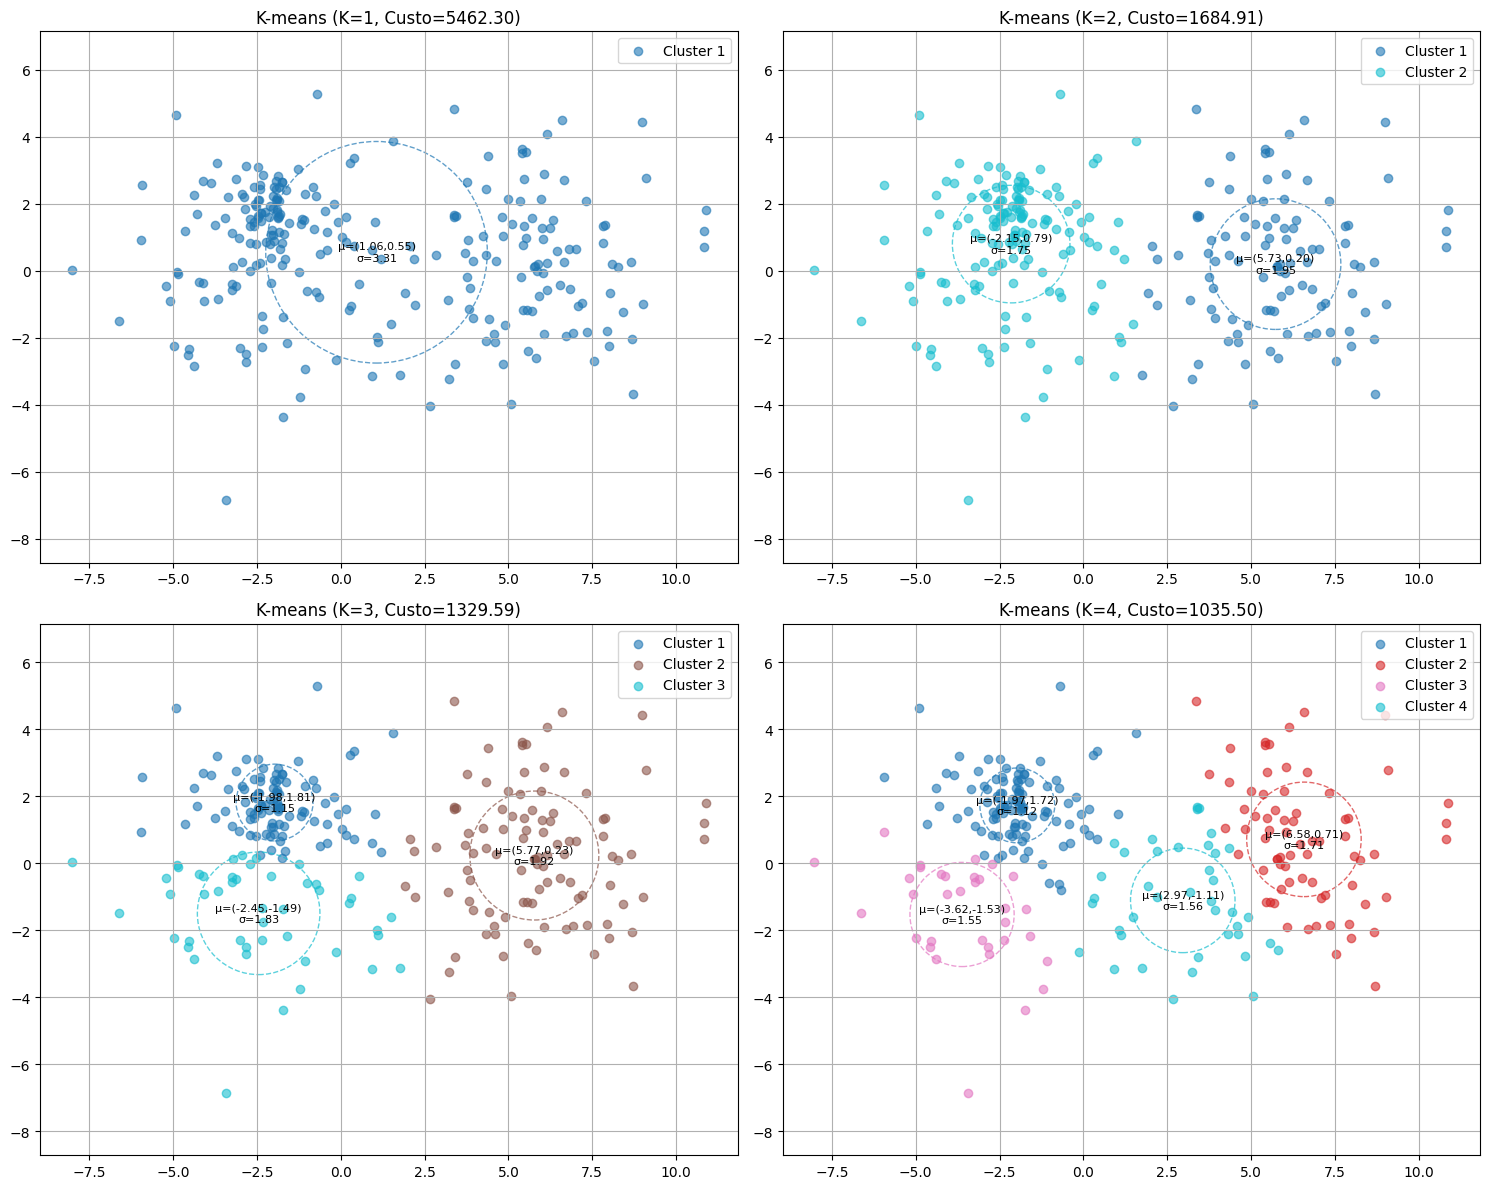

In [8]:
# Configurações dos testes
K_VALUES = [1, 2, 3, 4]
SEEDS = [0, 1, 2, 3, 4]

# ================== TESTE DO K-MEANS ==================
print("\n========== Teste: K-means ==========")
plt.figure(figsize=(15, 12))
for idx, K in enumerate(K_VALUES):
    best_cost = np.inf
    best_mixture = None

    for seed in SEEDS:
        np.random.seed(seed)
        mu_init = X[np.random.choice(X.shape[0], K, replace=False)]
        initial_mixture = GaussianMixture(mu_init, np.ones(K), np.ones(K)/K)
        mixture, post, cost = kmeans_run(X, initial_mixture)

        if cost < best_cost:
            best_cost = cost
            best_mixture = mixture
            best_post = post

    ax = plt.subplot(2, 2, idx + 1)
    plot(X, best_mixture, best_post, f"K-means (K={K}, Custo={best_cost:.2f})", ax=ax)
plt.tight_layout()
plt.show()

In [14]:
# @title ========== Resultado do Teste: **K-means** ==========
print(f"\nMelhor custo para K-means com K: {best_K}: {best_cost}")


Melhor custo para K-means com K: 4: 1035.4998265394659



========== Teste: GMM EM ==========
Iteração 1: Log-verossimilhança = -1778.85
Iteração 2: Log-verossimilhança = -1307.22
Iteração 3: Log-verossimilhança = -1307.22
Convergido após 3 iterações.
Iteração 1: Log-verossimilhança = -1633.39
Iteração 2: Log-verossimilhança = -1307.22
Iteração 3: Log-verossimilhança = -1307.22
Convergido após 3 iterações.
Iteração 1: Log-verossimilhança = -1349.19
Iteração 2: Log-verossimilhança = -1307.22
Iteração 3: Log-verossimilhança = -1307.22
Convergido após 3 iterações.
Iteração 1: Log-verossimilhança = -1503.27
Iteração 2: Log-verossimilhança = -1307.22
Iteração 3: Log-verossimilhança = -1307.22
Convergido após 3 iterações.
Iteração 1: Log-verossimilhança = -1438.36
Iteração 2: Log-verossimilhança = -1307.22
Iteração 3: Log-verossimilhança = -1307.22
Convergido após 3 iterações.
BIC para K=1: -1315.51
Iteração 1: Log-verossimilhança = -1310.43
Iteração 2: Log-verossimilhança = -1191.21
Iteração 3: Log-verossimilhança = -1177.84
Iteração 4: Log-veros

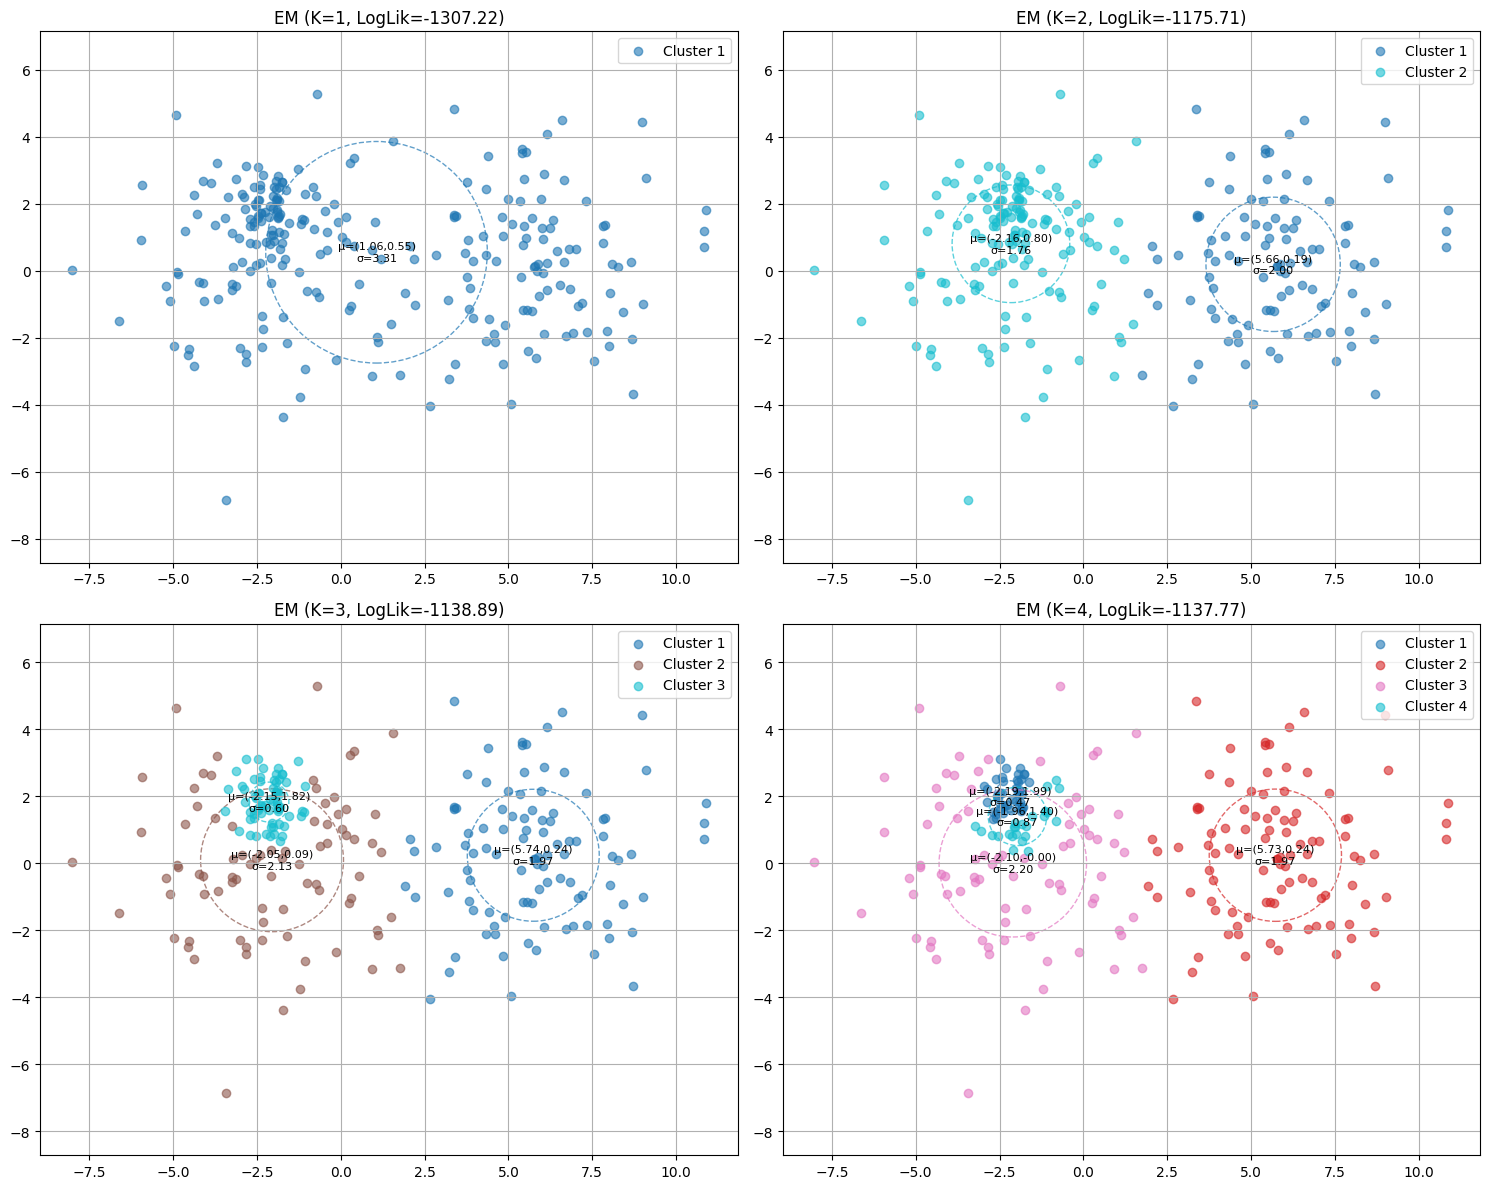

In [9]:
# @title **Função `BIC` (Critério de Informação Bayesiano)**
def bic(X: np.ndarray, mixture: GaussianMixture, log_likelihood: float) -> float:
    """Calcula o Critério de Informação Bayesiano para uma mistura de gaussianas

    Args:
        X: (n, d) array contendo os dados
        mixture: uma mistura de gaussianas esféricas
        log_likelihood: a log-verossimilhança dos dados

    Returns:
        float: o BIC para esta mistura
    """
    n, d = X.shape
    K = mixture.mu.shape[0]

    # número de parâmetros livres para uma mistura gaussiana esférica
    # K médias (cada uma com d dimensões), K variâncias e K-1 pesos
    num_params = K * d + K + (K - 1)
    bic_value = log_likelihood - 0.5 * num_params * np.log(n)
    return bic_value

# ================== TESTE DO EM (Expectation-Maximization) ==================
print("\n========== Teste: GMM EM ==========")
plt.figure(figsize=(15, 12))
for idx, K in enumerate(K_VALUES):
    best_loglik = -np.inf

    for seed in SEEDS:
        np.random.seed(seed)
        mu_init = X[np.random.choice(X.shape[0], K, replace=False)]
        initial_mixture = GaussianMixture(mu_init, np.var(X)*np.ones(K), np.ones(K)/K)
        mixture, post, loglik = gmm_run(X, initial_mixture)

        if loglik > best_loglik:
            best_loglik = loglik
            best_mixture = mixture
            best_post = post

    bic_value = bic(X, best_mixture, best_loglik)
    print(f"BIC para K={K}: {bic_value:.2f}")

    ax = plt.subplot(2, 2, idx + 1)
    plot(X, best_mixture, best_post, f"EM (K={K}, LogLik={best_loglik:.2f})", ax=ax)
plt.tight_layout()
plt.show()

In [19]:
# @title ========== Resultado do Teste: **GMM EM** ==========
print("\nResultados para GMM EM:")
print("-" * 50)
print("{:<5} {:<20} {:<10} {:<10}".format("K", "Log-Verossimilhança", "Seed", "BIC"))
print("-" * 50)

for result in results:
    print("{:<5} {:<20.2f} {:<10} {:<10.2f}".format(result['K'], result['Log-Verossimilhança'], result['Seed'], result['BIC']))

print("-" * 50)


Resultados para GMM EM:
--------------------------------------------------
K     Log-Verossimilhança  Seed       BIC       
--------------------------------------------------
1     -1307.22             0          -1315.51  
2     -1175.71             2          -1195.04  
3     -1138.89             0          -1169.26  
4     -1137.77             4          -1179.18  
--------------------------------------------------
